In [1]:
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")

NameError: name 'sns' is not defined

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv('D:\Study\Codeneara\Project\Finace_Project\Loan_Approval_Rrisk_Pattern_Analysis\Data.csv')

df.head()

,customer_id,age,gender,education,employment_type,employment_length,annual_income,existing_emi,debt_to_income_ratio,cibil_score,...,city,area_type,loan_approval_time_days,document_verification_status,loan_approval_status,rejection_reason,EMI,EMI_to_Income_Ratio,risk_rule,Loan_to_Income_Ratio
0,1,40,Male,Graduate,Salaried,21,737179,6113,0.20,654,...,Bathinda,Urban,3,Processing,Approved,NaN,5924.93,0.10,Low,0.23
1,2,47,Male,Graduate,Salaried,9,640639,6780,0.15,518,...,Haldia,Urban,5,Done,Rejected,Low Income,1241.85,0.02,Low,0.10
2,3,43,Male,Graduate,Salaried,23,666628,6926,0.16,462,...,Alwar,Urban,13,Processing,Approved,NaN,2188.67,0.04,Low,0.25
3,4,28,Female,Graduate,Self-employed,23,1143020,17211,0.23,492,...,Jorhat,Urban,3,Done,Rejected,High Existing EMI,4961.03,0.05,Low,0.21
4,5,51,Male,Graduate,Salaried,30,366810,15839,0.55,507,...,Aurangabad,Rural,1,Done,Approved,NaN,924.23,0.03,Low,0.14


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   3000 non-null   int64  
 1   age                           3000 non-null   int64  
 2   gender                        3000 non-null   object 
 3   education                     3000 non-null   object 
 4   employment_type               3000 non-null   object 
 5   employment_length             3000 non-null   int64  
 6   annual_income                 3000 non-null   int64  
 7   existing_emi                  3000 non-null   int64  
 8   debt_to_income_ratio          3000 non-null   float64
 9   cibil_score                   3000 non-null   int64  
 10  credit_utilization_ratio      3000 non-null   float64
 11  previous_default              3000 non-null   object 
 12  loan_amount                   3000 non-null   int64  
 13  loa

customer_id                        0
age                                0
gender                             0
education                          0
employment_type                    0
employment_length                  0
annual_income                      0
existing_emi                       0
debt_to_income_ratio               0
cibil_score                        0
credit_utilization_ratio           0
previous_default                   0
loan_amount                        0
loan_type                          0
loan_purpose                       0
loan_tenure_years                  0
interest_rate                      0
risk_category                      0
lender_type                        0
loan_processing_fee_percent        0
application_channel                0
state                              0
city                               0
area_type                          0
loan_approval_time_days            0
document_verification_status       0
loan_approval_status               0
r

In [20]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

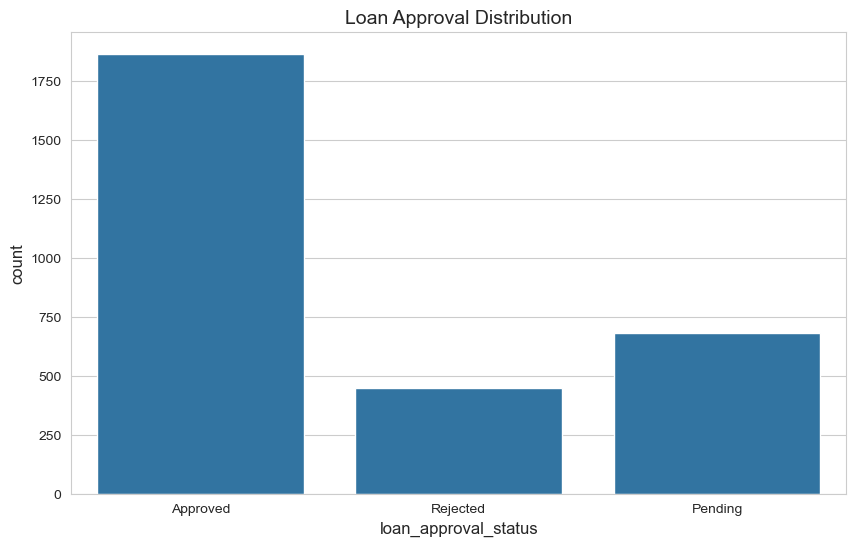

In [26]:
# Loan Approval Distribution

import matplotlib.pyplot as plt
import seaborn as sns
plt.tight_layout()
sns.set_style("whitegrid")

sns.countplot(x='loan_approval_status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

# Insight:
# The dataset shows that a higher proportion of applications are approved compared to rejected.
# This indicates either lenient approval policies or a pre-screened applicant pool.

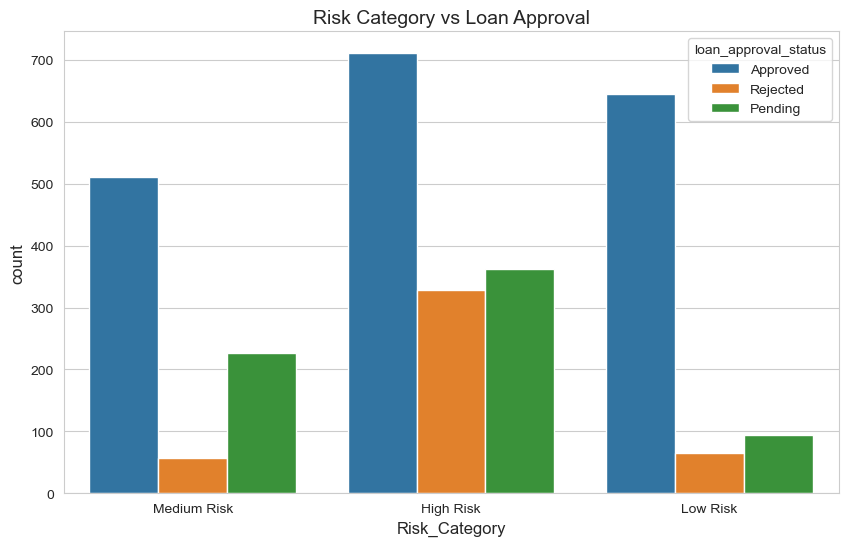

In [27]:
# Risk Category vs Loan Approval

import matplotlib.pyplot as plt
import seaborn as sns
plt.tight_layout()
def risk_category(score):
    if score >= 750:
        return "Low Risk"
    elif score >= 650:
        return "Medium Risk"
    else:
        return "High Risk"

df['Risk_Category'] = df['cibil_score'].apply(risk_category)
sns.countplot(x='Risk_Category', hue='loan_approval_status', data=df)
plt.title("Risk Category vs Loan Approval")
plt.show()



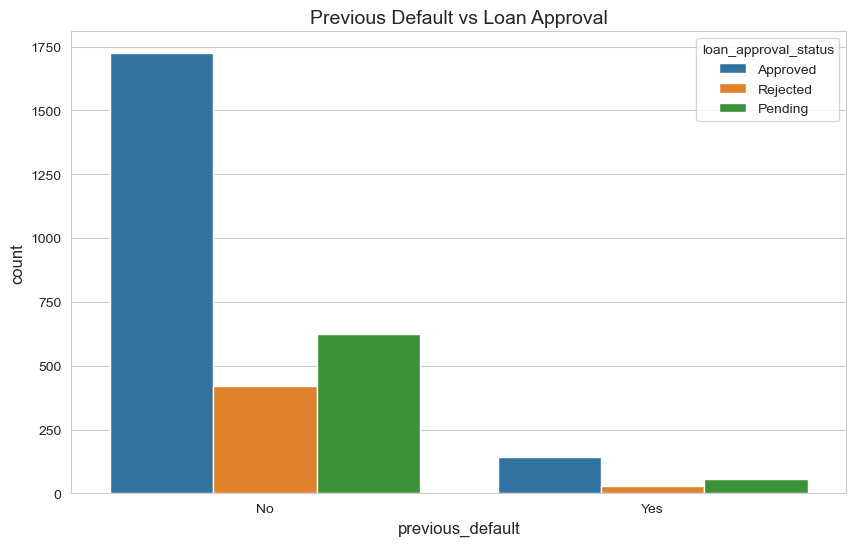

In [28]:
# Previous Default vs Loan Approval
plt.tight_layout()
sns.countplot(x='previous_default', hue='loan_approval_status', data=df)
plt.title("Previous Default vs Loan Approval")
plt.show()

# Insight:
# Applicants with previous loan defaults have a much higher rejection rate,
# showing that past repayment behavior strongly influences approval decisions.

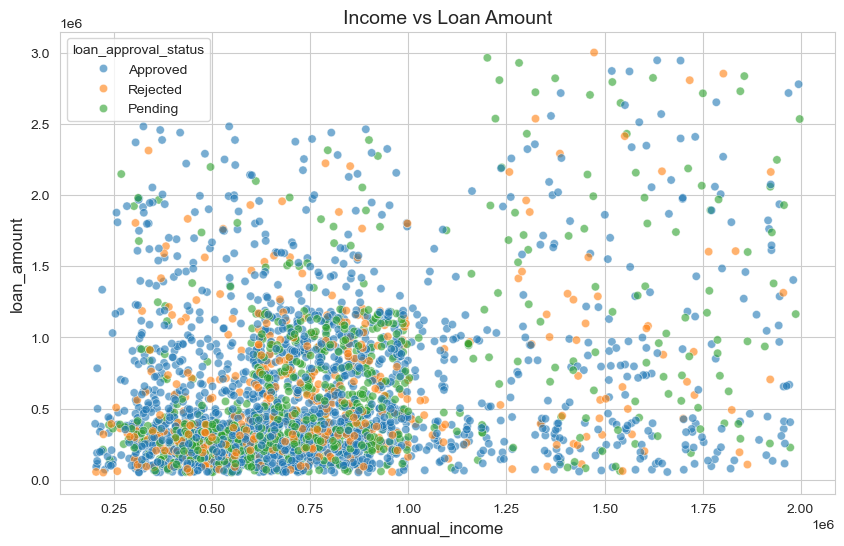

In [43]:
# Income vs Loan Amounts
sns.scatterplot(
    x='annual_income',
    y='loan_amount',
    hue='loan_approval_status',
    data=df,
    alpha=0.6
)

plt.title("Income vs Loan Amount")
plt.show()
# Insight:
# Although higher income applicants tend to request larger loans,
# income alone does not guarantee loan approval, indicating other factors are considered.

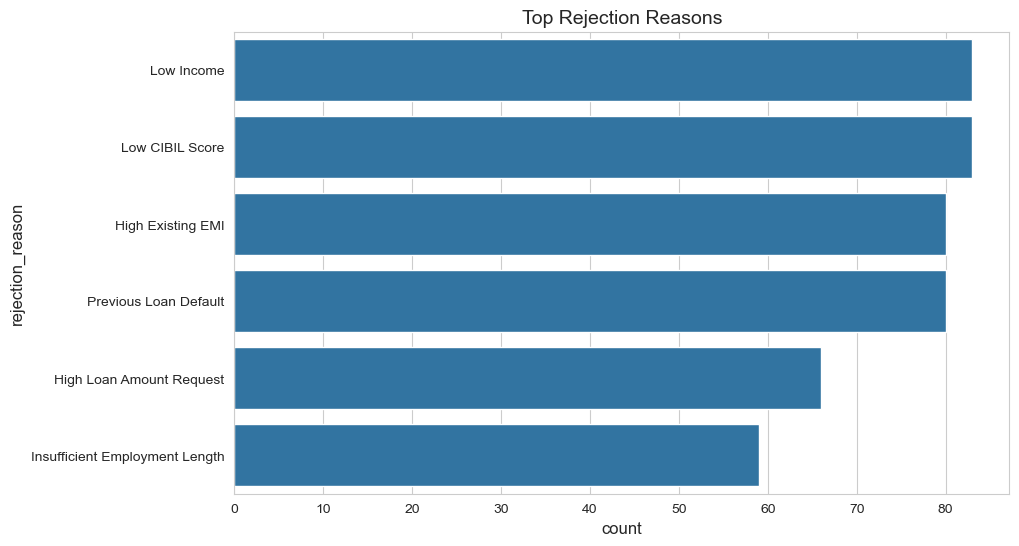

In [37]:
# Rejection Reasons
plt.tight_layout()
rejected = df[df['loan_approval_status'] == 'Rejected']

sns.countplot(y='rejection_reason', data=rejected, order=rejected['rejection_reason'].value_counts().index)
plt.title("Top Rejection Reasons")
plt.show()

# Insight:
# The most common rejection reasons include low credit score and high debt burden,
# indicating that financial risk indicators dominate decision-making.

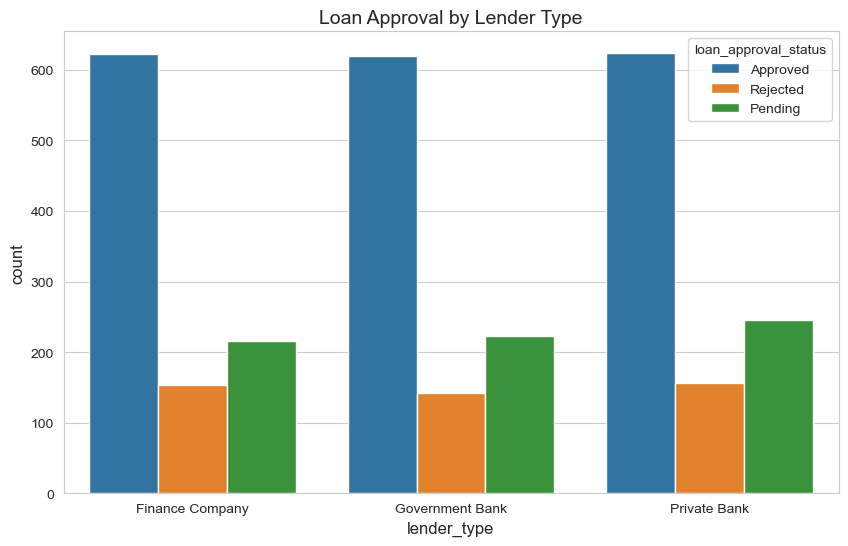

In [32]:
# Lender Type vs Loan Approval
plt.tight_layout()
sns.countplot(x='lender_type', hue='loan_approval_status', data=df)
plt.title("Loan Approval by Lender Type")
plt.show()

# Insight:
# Different lender types show variation in approval rates,
# suggesting differences in risk appetite and lending policies.

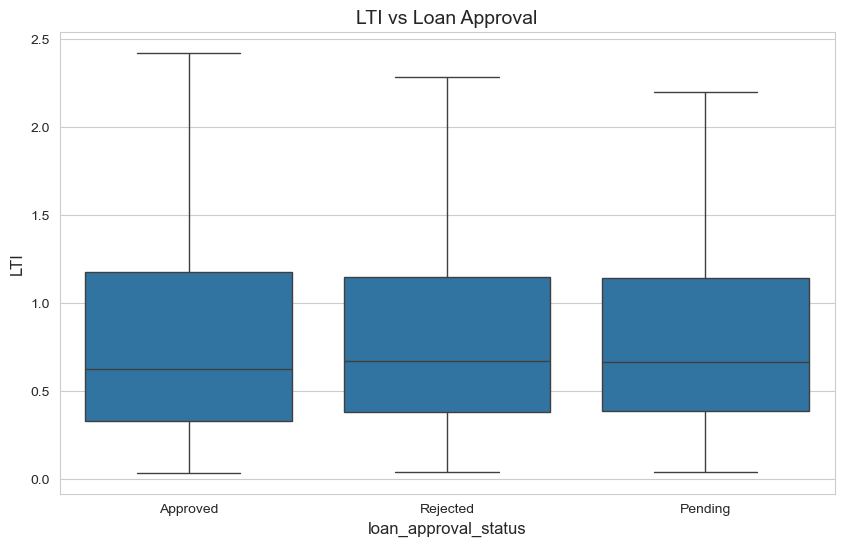

In [33]:
# Loan-to-Income Ratio (LTI) vs Approval
plt.tight_layout()
sns.boxplot(
    x='loan_approval_status',
    y='LTI',
    data=df,
    showfliers=False
)
plt.title("LTI vs Loan Approval")
plt.show()
# Insight:
# Applicants with higher loan-to-income ratios are more likely to be rejected,
# as higher financial burden increases default risk.

In [ ]:
# FINAL BUSINESS INSIGHTS

# 1. Credit score (CIBIL) is the most influential factor in loan approval decisions.
# 2. Applicants with previous defaults have significantly lower approval chances.
# 3. Financial ratios like LTI and DTI are strong indicators of risk.
# 4. Income alone is not sufficient; multiple factors drive approval decisions.
# 5. Rejection reasons highlight key risk parameters such as credit score and debt burden.
# 6. Lending behavior varies across lender types, reflecting different risk strategies.